In [2]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [3]:
# Make output folder
output_dir = os.path.join('..','plots','behavioural_pilot', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [4]:
# Preparation
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')

In [5]:
unique_subject_ids = [998]
unique_sessions = [0, 1, 2]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)

In [6]:
print(recent_results)

['../../phd_1_task/experiment_output/behavioural_files/experiment_output_sub-998_session-00_computer_and_keyboard_2024-06-12_18-02-24.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-998_session-01_debug_2024-06-20_09-08-59.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-998_session-02_debug_2024-06-19_17-11-46.csv']


In [7]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.718208e+09     down                Even   
1         1        1.718208e+09     down                Even   
2         2        1.718208e+09     down                Even   
3         3        1.718208e+09       up                Even   
4         4        1.718208e+09       up                Even   
...     ...                 ...      ...                 ...   
2035    675        1.718814e+09     down                True   
2036    676        1.718814e+09       up                True   
2037    677        1.718814e+09     down                True   
2038    678        1.718814e+09     down                True   
2039    679        1.718814e+09       up                True   

     subjectively_correct  response_time   RT_s  stimuli_type  iti  \
0                    True   1.718208e+09  0.965             3    2   
1                    True   1.718208e+09  0.455             1    2   
2                   F

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [8]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional column for congruency

In [9]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition   congruency
0                3                     50    undefined
1                1                     50    undefined
2                1                     50    undefined
3                3                     50    undefined
4                3                     50    undefined
...            ...                    ...          ...
2035             3                     20  incongruent
2036             1                     80  incongruent
2037             3                     20  incongruent
2038             3                     20  incongruent
2039             1                     80  incongruent

[2040 rows x 3 columns]


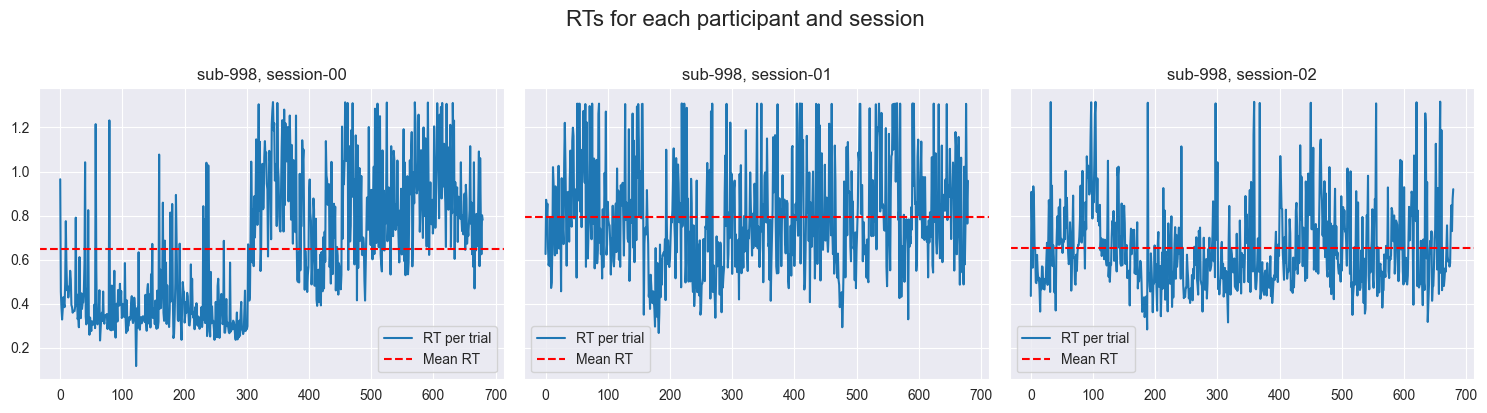

In [10]:
# Subplots for RT
## Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharex=True, sharey=True)
fig.suptitle('RTs for each participant and session', fontsize=16, y=1.02)

if n_rows == 1 or n_cols == 1:
    axes = np.array(axes).reshape(n_rows, n_cols)

## Loop through each combination of 'session' and 'subject_id' and create a plot
for i, session in enumerate(unique_sessions):
    for j, subject_id in enumerate(unique_subject_ids):
        ax_index = j * len(unique_sessions) + i
        ax = axes[j, i]

        ## Filter the dataframe for the current session and subject_id
        subset = combined_results_dataframe[(combined_results_dataframe['session'] == session) & (combined_results_dataframe['subject_id'] == subject_id)]

        ## Plot
        ax.plot(subset['RT_s'].values, label=f'RT per trial')
        ax.axhline(subset['RT_s'].mean(), color='r', linestyle='--', label='Mean RT')
        ax.set_title(f'{subject_id}, {session}')
        ax.legend()

## Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'RT_for_each_participant_and_session.pdf'))
plt.show()

Analyse response time for happy-angry approach-avoid, check manuscript


In [11]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

# Statistics
Start by checking if the objectively correct answers significantly differ from chance

In [12]:
# Filter out trials with 50% reward probability and without responses
stats_dataframe = combined_results_dataframe.drop(combined_results_dataframe[(combined_results_dataframe.probability_condition == 50) | (combined_results_dataframe.objectively_correct == 'Late')].index, inplace=False)
# Calculate the total number of successes and the total number of trials
total_successes = stats_dataframe['objectively_correct_boolean'].sum()
total_trials = len(stats_dataframe)

# Calculate expected successes and failures if each trial has a 50% chance of success
expected_successes = total_trials * 0.5
expected_failures = total_trials * 0.5

# Perform the chi-square goodness of fit test
chi2_stat, p_value = chisquare([total_successes, total_trials - total_successes],
                               f_exp=[expected_successes, expected_failures])

print(chi2_stat, p_value)

15.83640081799591 6.906106929926742e-05


In [13]:
# Multiply the boolean response by 100 to get percentages, can only do this after the stats
combined_results_dataframe['objectively_correct_boolean'] *= 100

# Objectively correct answer binned after every switch

In [14]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0

objectively_correct_answers_per_switch_block = pd.DataFrame()

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]
        
        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        
        # Filter out trials with 50% reward probability and without responses
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.drop(combined_results_grouped_dataframe[(combined_results_grouped_dataframe.probability_condition == 50) | (combined_results_grouped_dataframe.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.reset_index()
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()
        print(f'{index_stimuli}, {index_subject_id}, {switches_reward}')
        
        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = dataframe_containing_groups_filtered.iloc[values:values+13]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 10: 8, 11: 9, 12: 10, 13: 11, 14: 12})

3, sub-998, [0, 28, 60, 70, 82, 92, 104, 136, 164, 177, 187, 201, 213, 244, 271, 284, 304, 318, 330, 385, 405, 415, 427, 457, 484, 496, 506, 528, 559, 592, 600, 611, 624, 636, 668, 695, 709, 719, 731, 743, 771, 802, 812, 822, 836, 848, 876, 907, 921, 931, 943, 957]
1, sub-998, [0, 28, 60, 70, 82, 92, 104, 136, 163, 176, 186, 200, 212, 242, 270, 284, 294, 306, 319, 331, 358, 399, 410, 420, 432, 463, 491, 505, 514, 528, 540, 571, 599, 613, 623, 635, 648, 659, 690, 717, 731, 741, 752, 764, 792, 824, 833, 842, 856, 868, 895, 927, 941, 951, 962, 976]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5157/1628670542.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5157/1628670542.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)


hello


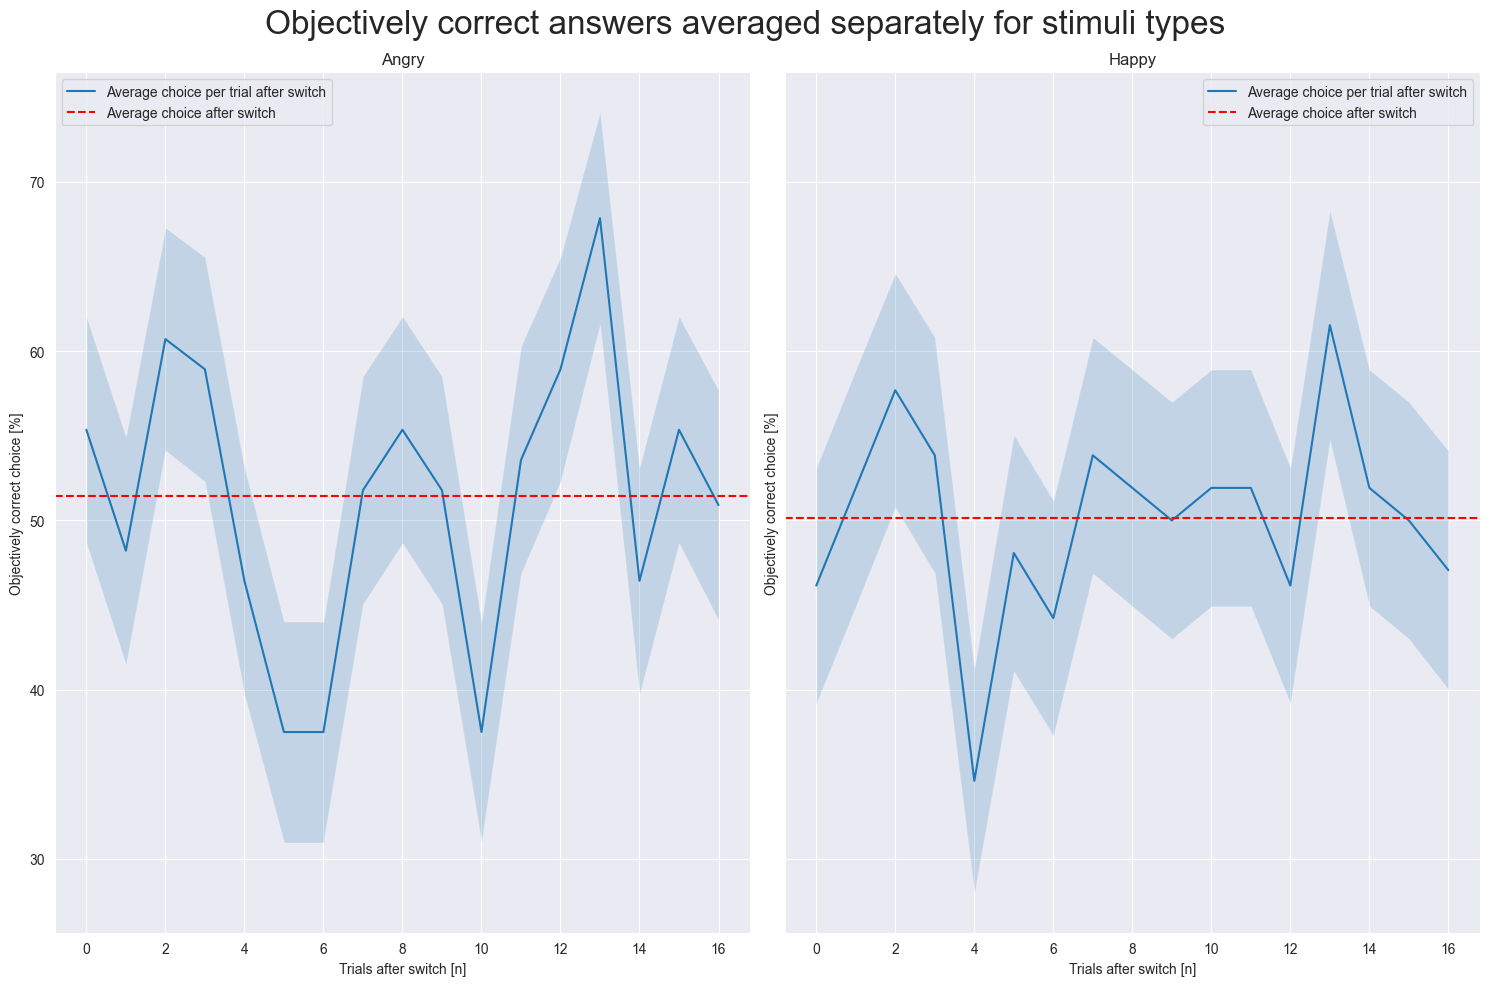

In [32]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged separately for stimuli types', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = np.arange(len(means.columns))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches-0_12.pdf'))
plt.show()

## objectively correct answers without binning
Now we'll look at the objectively correct answers in a sequential manner, so without binning them based on switches in reward contingencies.
Plot probability of correct response on Y-axis to trials on X-axis

In [16]:
# Take the mean from all 12 trials after each switch
trials_after_switch_to_plot = list(range(0,13))
intermediate_dataframe = objectively_correct_answers_per_switch_block
intermediate_dataframe['switch_number'] = intermediate_dataframe.groupby(['subject_id','stimuli_type']).cumcount()
print(intermediate_dataframe)

# Preparation for loop
unique_switches = intermediate_dataframe['switch_number'].unique()
column_names = ['stimuli_type', 'switch'] + trials_after_switch_to_plot
objectively_correct_answers_averaged_per_switch_block = pd.DataFrame(columns = column_names)

# Loop through each stimulus and switch type
for index_stimuli, value_stimuli in enumerate(unique_stimuli_types):
    for index_switch, value_switch in enumerate(unique_switches):
        filtered_dataframe = intermediate_dataframe[(intermediate_dataframe['stimuli_type'] == value_stimuli) & (intermediate_dataframe['switch_number'] == value_switch)]
        list_with_averages = [value_stimuli, value_switch] + (filtered_dataframe[trials_after_switch_to_plot].mean()).to_list()
        objectively_correct_answers_averaged_per_switch_block.loc[len(objectively_correct_answers_averaged_per_switch_block)] = list_with_averages

objectively_correct_answers_averaged_per_switch_block['mean'] = objectively_correct_answers_averaged_per_switch_block[trials_after_switch_to_plot].mean(axis=1)

    subject_id  stimuli_type    0    1    2    3    4    5    6    7    8  \
0      sub-998             3    0    0  100    0    0    0    0    0  100   
1      sub-998             3  100  100  100  100    0    0    0    0  100   
2      sub-998             3    0  100  100    0  100  100  100  100    0   
3      sub-998             3  100  100  100    0  100  100    0    0  100   
4      sub-998             3    0    0    0    0    0  100    0    0  100   
..         ...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
103    sub-998             1  100  100    0  100    0  100    0  100  100   
104    sub-998             1  100    0  100    0  100    0    0    0    0   
105    sub-998             1    0    0    0  100  100    0    0  100  100   
106    sub-998             1  100    0    0  100  100    0    0  100    0   
107    sub-998             1    0    0    0  100  100    0  100  100  100   

       9   10     11     12  switch_number  
0    100  100  100.0    0.0   

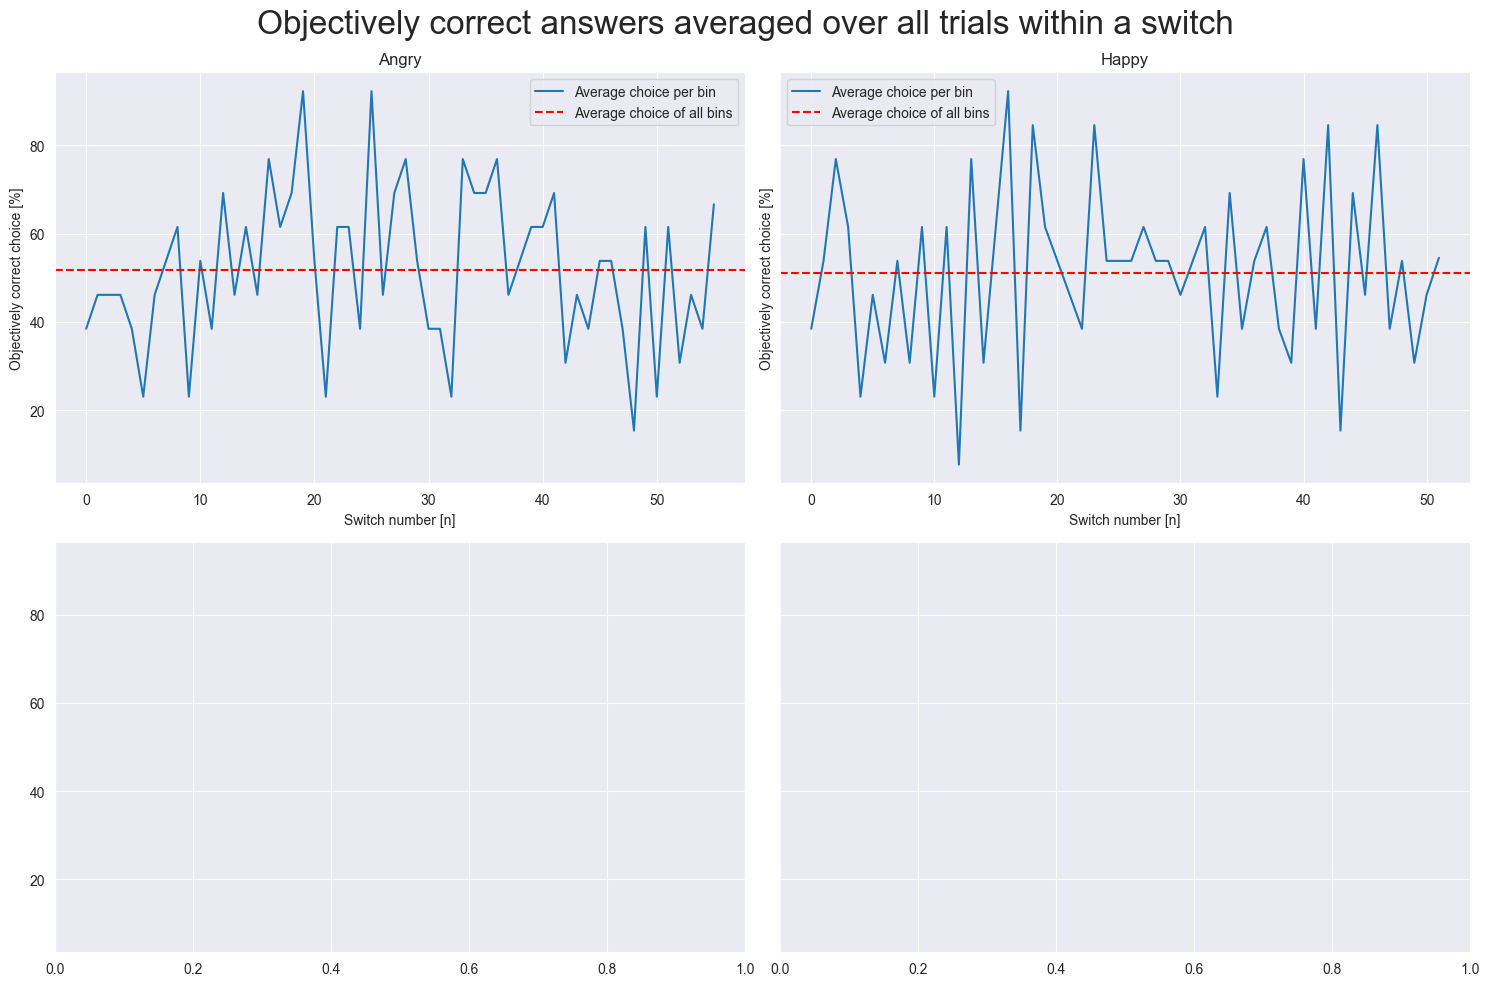

In [17]:
# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged over all trials within a switch', fontsize=24, y=0.982)

for index_stimuli, value_stimuli in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    filtered_dataframe = objectively_correct_answers_averaged_per_switch_block[objectively_correct_answers_averaged_per_switch_block['stimuli_type'] == value_stimuli]

    axs[index_stimuli].plot(unique_switches, filtered_dataframe['mean'], label='Average choice per bin')
    axs[index_stimuli].axhline((average_choice_after_switch_total[index_stimuli]), color='r', linestyle='--', label='Average choice of all bins')
    axs[index_stimuli].set_title(stimuli_types_list[index_stimuli])
    axs[index_stimuli].set_xlabel('Switch number [n]')
    axs[index_stimuli].set_ylabel('Objectively correct choice [%]')
    axs[index_stimuli].legend()
    axs[index_stimuli].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_trials_within_switch.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [18]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-12, 5))

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values-12:values+5]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: -12, 3: -11, 4: -10, 5: -9, 6: -8, 7: -7, 8: -6, 9: -5, 10: -4, 11: -3, 12: -2, 13: -1, 14: 0, 15: 1, 16: 2, 17: 3, 18: 4})

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5157/3754995200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5157/3754995200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)


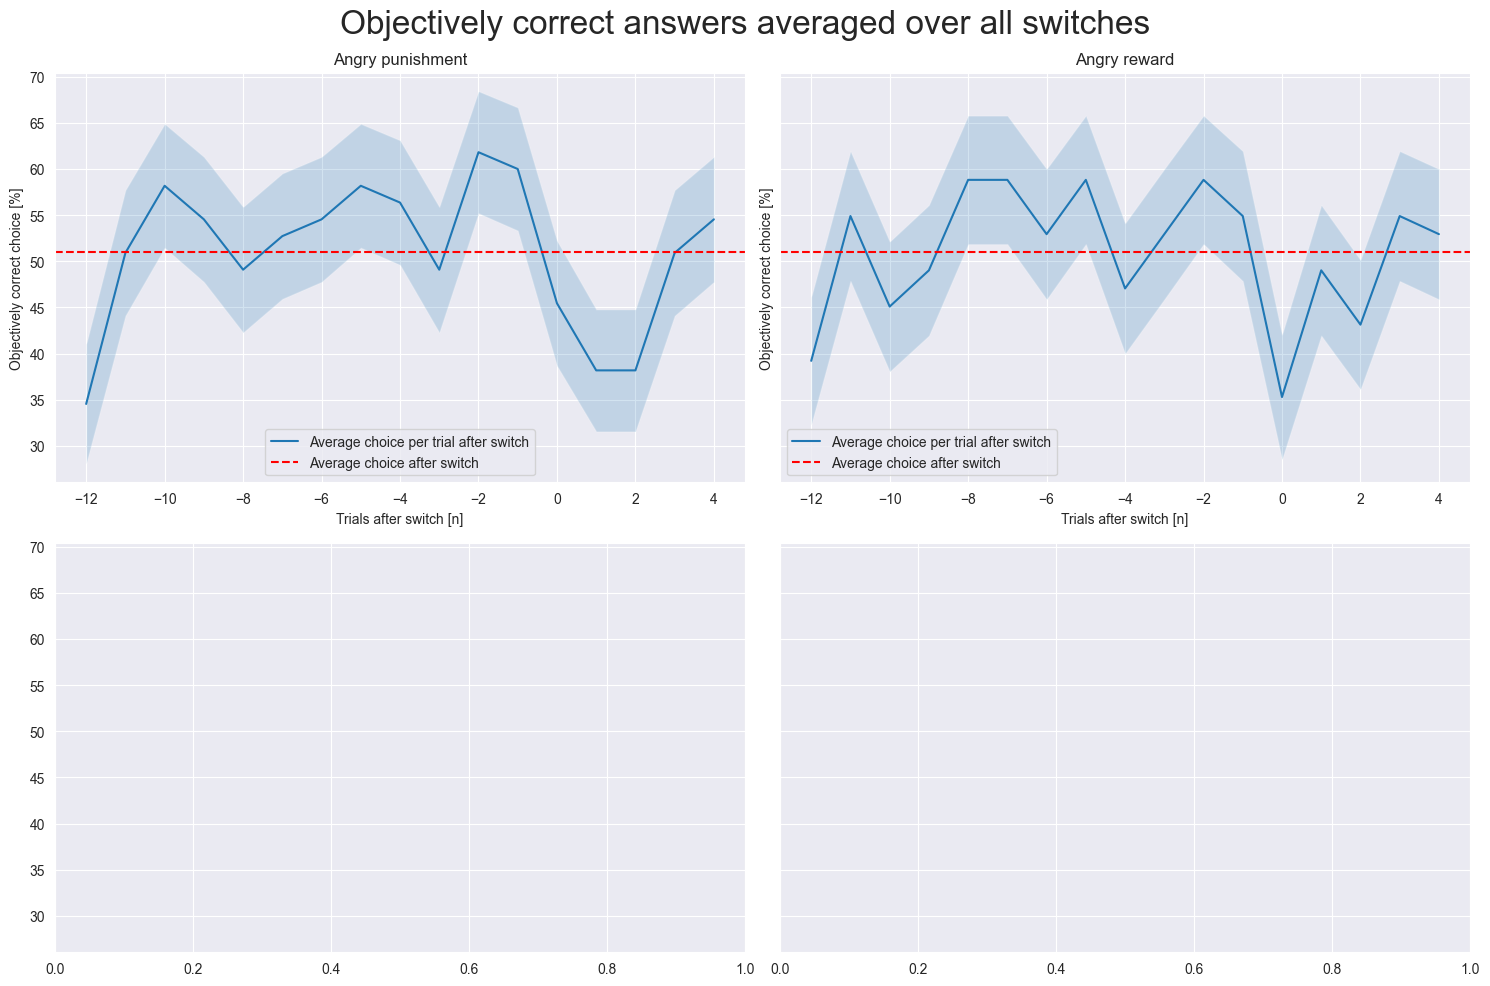

In [19]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged over all switches', fontsize=24, y=0.982)

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches-12_4.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 4 trials before the switch and ending 12 after.

In [20]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-4, 13))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: -4, 3: -3, 4: -2, 5: -1, 6: 0, 7: 1, 8: 2, 9: 3, 10: 4, 11: 5, 12: 6, 13: 7, 14: 8, 15: 9, 16: 10, 17: 11, 18: 12}

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values+min(plot_range):values+max(plot_range)+1]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns=mapping)
print(objectively_correct_answers_per_switch_block)

    subject_id  stimuli_type   -4   -3   -2   -1    0    1    2    3    4  \
0      sub-998             3    0    0    0    0    0    0  100    0    0   
1      sub-998             3  100  100  100    0  100  100  100  100    0   
2      sub-998             3    0  100  100    0    0  100  100    0  100   
3      sub-998             3  100  100    0  100  100  100  100    0  100   
4      sub-998             3  100    0  100  100    0    0    0    0    0   
..         ...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
103    sub-998             1  100    0    0    0  100  100    0  100    0   
104    sub-998             1  100  100    0    0  100    0  100    0  100   
105    sub-998             1    0    0    0  100    0    0    0  100  100   
106    sub-998             1    0  100    0  100  100    0    0  100  100   
107    sub-998             1    0    0  100    0    0    0    0  100  100   

       5    6    7    8    9   10   11     12  
0      0    0    0  100  10

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5157/2712700415.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5157/2712700415.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)


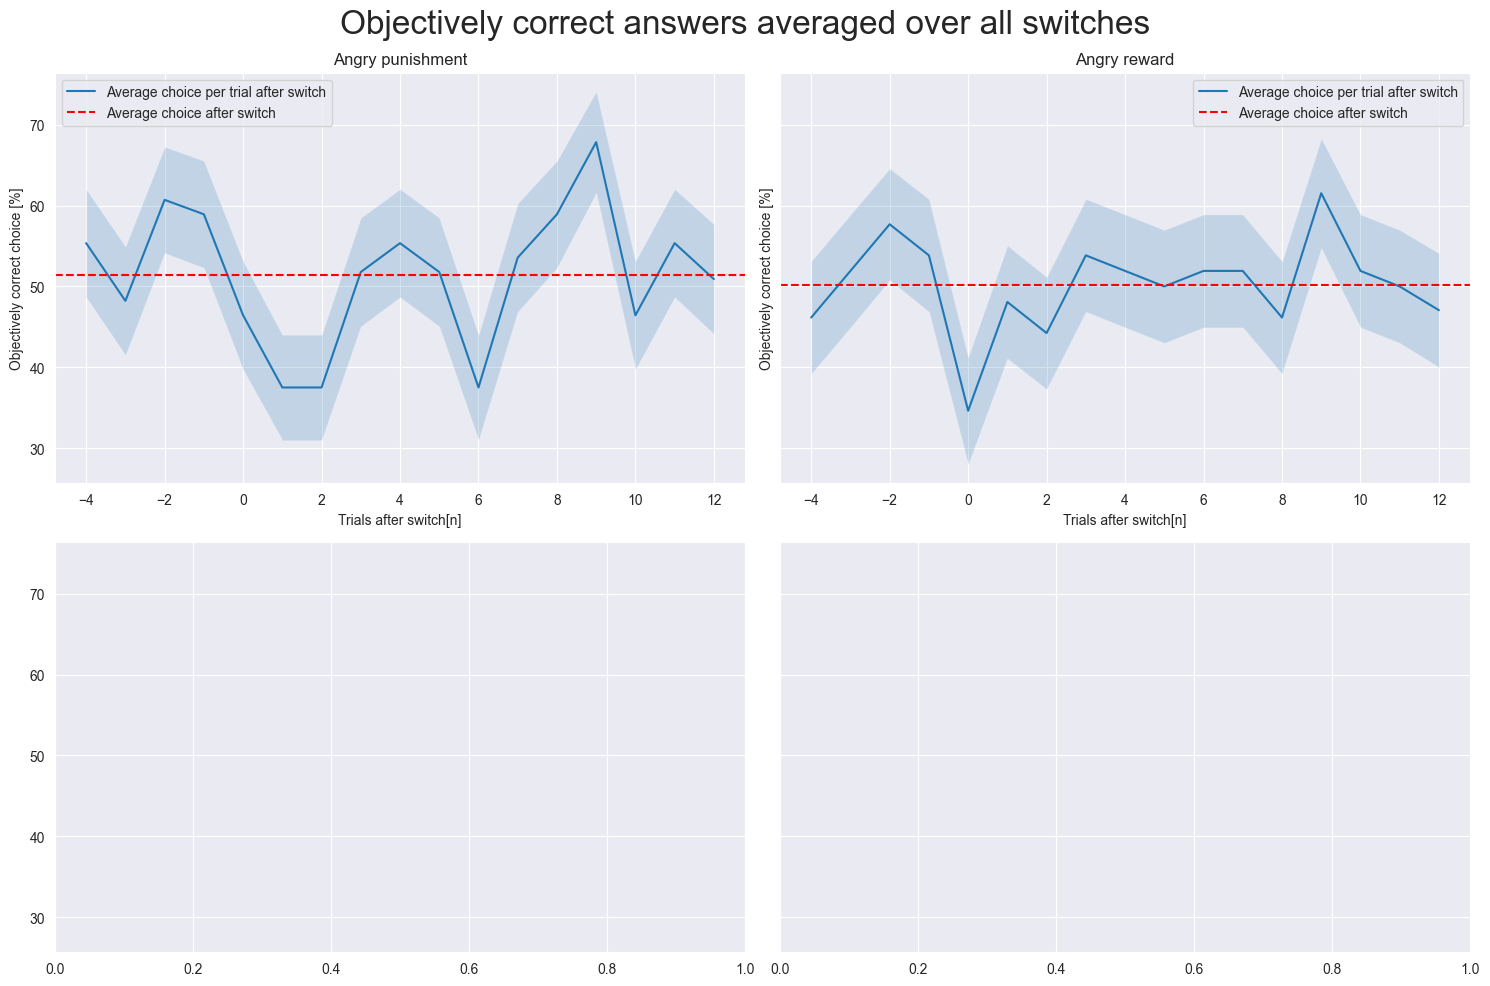

In [21]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged over all switches', fontsize=24, y=0.982)

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch[n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches-4_12.pdf'))
plt.show()

# Subplots for incongruent and congruent switches

In [22]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 13))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                 unique_subject_ids,
                                                                 unique_stimuli_types,
                                                                 'congruency',
                                                                 plot_range,
                                                                 mapping)
print(all_switches_dataframe)

    stimuli_type  subject_id   congruency    0    1    2    3    4    5    6  \
0        sub-998           3    congruent    0    0  100    0    0    0    0   
1        sub-998           3    congruent    0  100  100    0  100  100  100   
2        sub-998           3    congruent    0    0    0    0    0  100    0   
3        sub-998           3    congruent    0    0    0    0    0    0  100   
4        sub-998           3    congruent    0  100  100    0    0    0  100   
..           ...         ...          ...  ...  ...  ...  ...  ...  ...  ...   
103      sub-998           1  incongruent  100  100    0    0  100    0  100   
104      sub-998           1  incongruent    0  100  100    0    0  100  100   
105      sub-998           1  incongruent  100  100    0  100    0  100    0   
106      sub-998           1  incongruent    0    0    0  100  100    0    0   
107      sub-998           1  incongruent    0    0    0  100  100    0  100   

       7    8    9   10     11     12  

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)


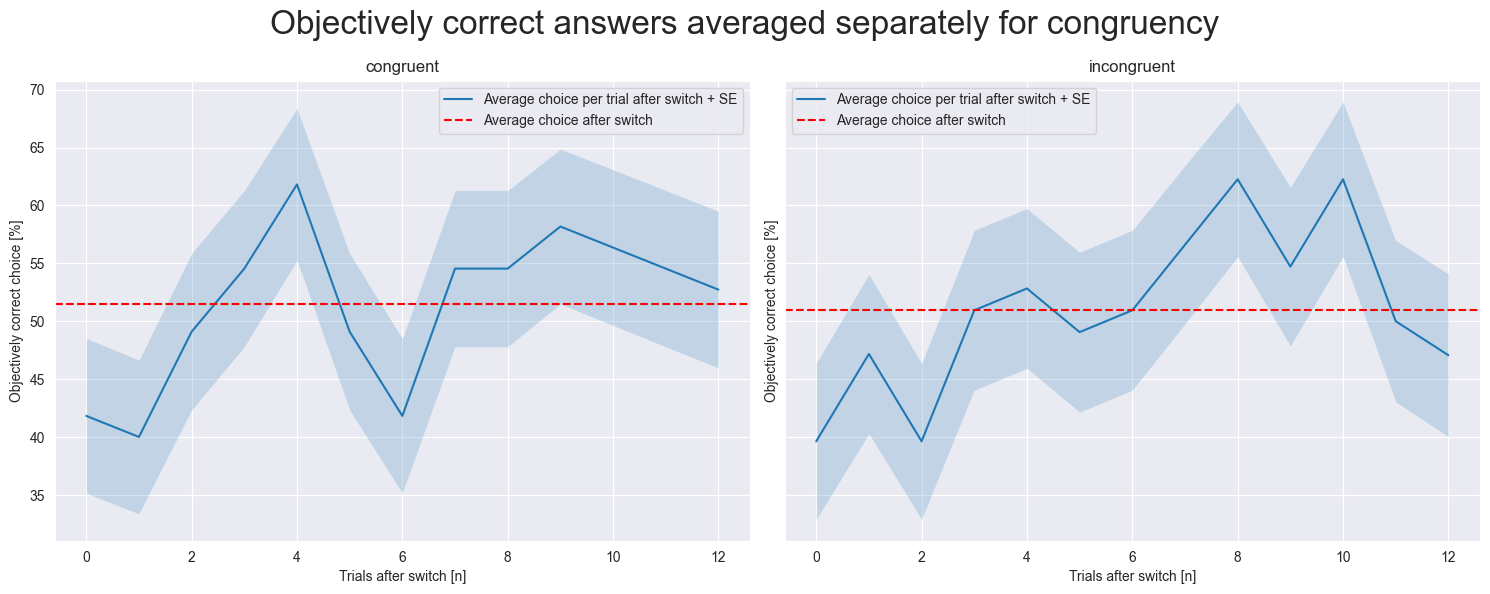

In [23]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged separately for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_congruency.pdf'))
plt.show()

# Subplots for reversal and non-reversal switches

In [24]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 13))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'all_reversals', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe_separate_reversals(combined_results_dataframe,
                                                                                          unique_subject_ids,
                                                                                          unique_stimuli_types,
                                                                                          plot_range,
                                                                                          mapping)
print(all_switches_dataframe)

    subject_id  stimuli_type  all_reversals    0    1    2    3    4    5  \
0      sub-998             3            1.0    0    0  100    0    0    0   
1      sub-998             3            1.0  100  100  100  100    0    0   
2      sub-998             3            1.0    0  100  100    0  100  100   
3      sub-998             3            1.0  100  100  100    0  100  100   
4      sub-998             3            1.0    0    0    0    0    0  100   
..         ...           ...            ...  ...  ...  ...  ...  ...  ...   
103    sub-998             1            1.0  100  100    0  100    0  100   
104    sub-998             1            1.0  100    0  100    0  100    0   
105    sub-998             1            1.0    0    0    0  100  100    0   
106    sub-998             1            1.0  100    0    0  100  100    0   
107    sub-998             1            1.0    0    0    0  100  100    0   

       6    7    8    9   10     11     12  
0      0    0  100  100  100  

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:579: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:579: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)


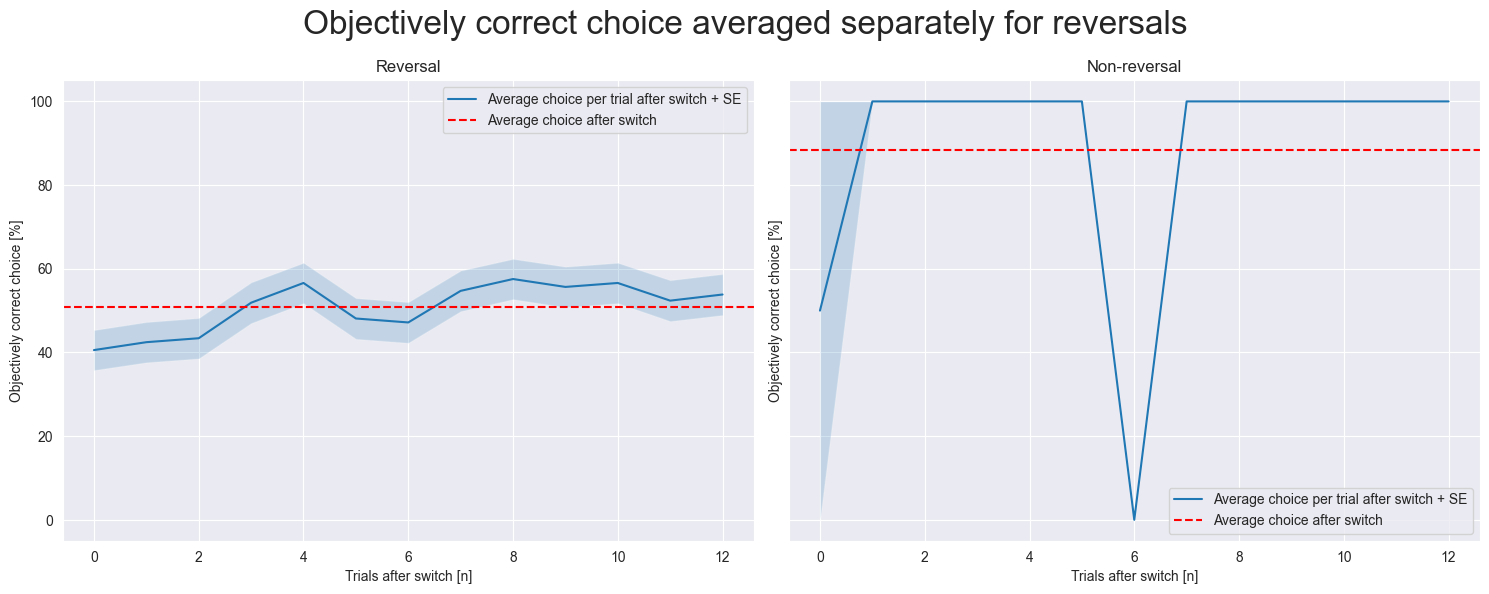

In [25]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('all_reversals')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('all_reversals').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('all_reversals').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False,
                        sharey=True)  # Adjust based on the number of stimuli_types
axs = axs.flatten()  # Flatten to iterate easily

fig.suptitle('Objectively correct choice averaged separately for reversals', fontsize=24, y=0.982)

reversal_list = ['Reversal','Non-reversal']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--',
                   label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(reversal_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_reversal.pdf'))
plt.show()

# Time before stabilisation
This will be the amount of trials before participants reach an average response of x%

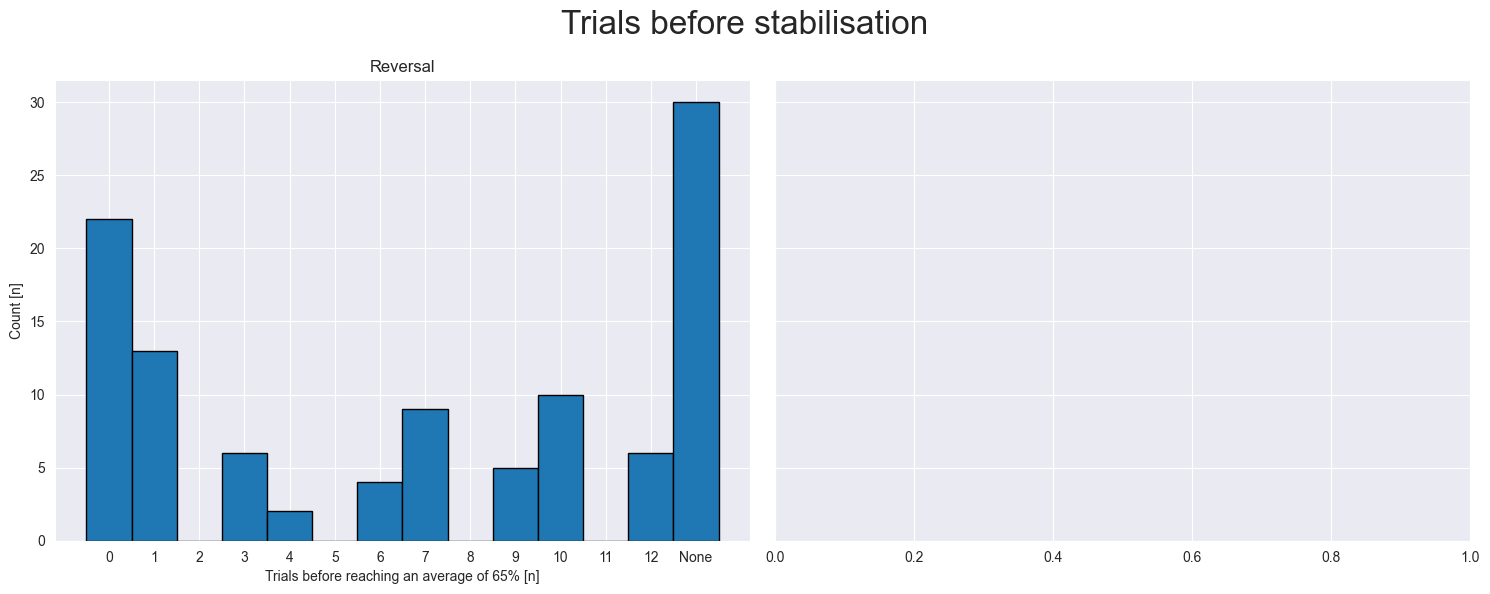

In [26]:
# Set some plotting guidelines
stable_performance = 65
bin_range = [0, 12]
sequence_bin_range = range(min(bin_range), max(bin_range) + 3)
sequence_tick_range = range(min(bin_range), max(bin_range) + 2)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)

fig.suptitle('Trials before stabilisation', fontsize=24, y=0.982)

# Bin edges centered around the ticks
bin_edges = [i - 0.5 for i in sequence_bin_range]

# Plot for switch value 1.0
reversal_results = utils.analysis_functions.trials_before_stabilisation(combined_results_dataframe, stable_performance, bin_range, 1.0)
axes[0].hist(reversal_results['number_of_trials_before_stabilising'], bins=bin_edges, edgecolor='black')
axes[0].set_title(reversal_list[0])
axes[0].set_xlabel(f'Trials before reaching an average of {stable_performance}% [n]')
axes[0].set_ylabel('Count [n]')
axes[0].set_xticks(sequence_tick_range)

ticks = axes[0].get_xticks()
tick_labels = axes[0].get_xticklabels()

# Replace the label at position 13 with None
tick_labels = [label.get_text() if tick != 13 else 'None' for tick, label in zip(ticks, tick_labels)]

# Set the new tick labels
axes[0].set_xticklabels(tick_labels)
'''
# Plot for switch value 2.0
nonreversal_results = utils.analysis_functions.trials_before_stabilisation(combined_results_dataframe, stable_performance, bin_range, 2.0)
axes[1].hist(nonreversal_results['number_of_trials_before_stabilising'], bins=bin_edges, edgecolor='black')
axes[1].set_title(reversal_list[1])
axes[1].set_xlabel(f'Trials before reaching an average of {stable_performance}% [n]')
axes[1].set_xticks(sequence_tick_range)

ticks = axes[1].get_xticks()
tick_labels = axes[1].get_xticklabels()

# Replace the label at position 13 with None
tick_labels = [label.get_text() if tick != 13 else 'None' for tick, label in zip(ticks, tick_labels)]

# Set the new tick labels
axes[1].set_xticklabels(tick_labels)
'''
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'trials_before_stabilisation.pdf'))
plt.show()

# Chance of a forward response around switch
Here, we plot the chance of a forward response around a switch, hoping to capture a flip in the switch for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [27]:
# First create a new dataframe with the 
bin_range = [-10, 10]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, bin_range) 

print(dataframe)

      trials_around_switch  response_int subject_id     session   congruency  \
0                        0             0    sub-998  session-00    congruent   
1                        1           100    sub-998  session-00    congruent   
2                        2           100    sub-998  session-00    congruent   
3                        3             0    sub-998  session-00    congruent   
4                        4             0    sub-998  session-00    congruent   
...                    ...           ...        ...         ...          ...   
2232                     6             0    sub-998  session-02  incongruent   
2233                     7           100    sub-998  session-02  incongruent   
2234                     8             0    sub-998  session-02  incongruent   
2235                     9             0    sub-998  session-02  incongruent   
2236                    10             0    sub-998  session-02  incongruent   

      stimuli_type                trans

['angry' 'happy'] ['congruent_to_incongruent' 'incongruent_to_congruent']


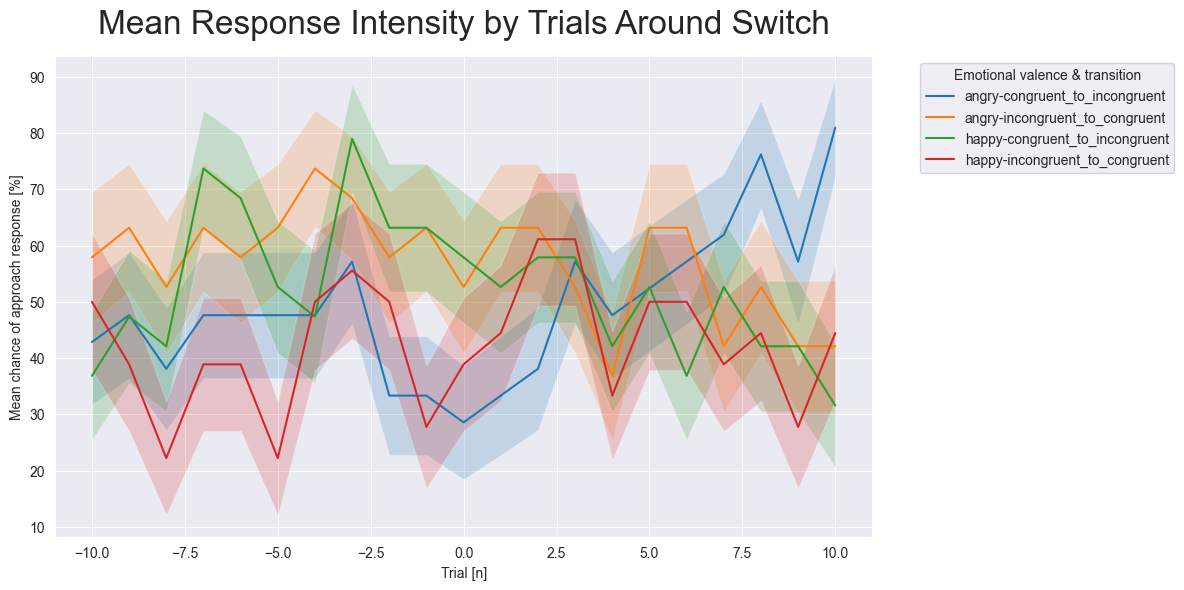

In [28]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(12, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']
print(emotional_valences, transitions)

# Plot each group
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Mean Response Intensity by Trials Around Switch', fontsize=24, y=1.03)
plt.legend(title='Emotional valence & transition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'Average response by emotional valence and transition.pdf'))
# Show the plot
plt.show()

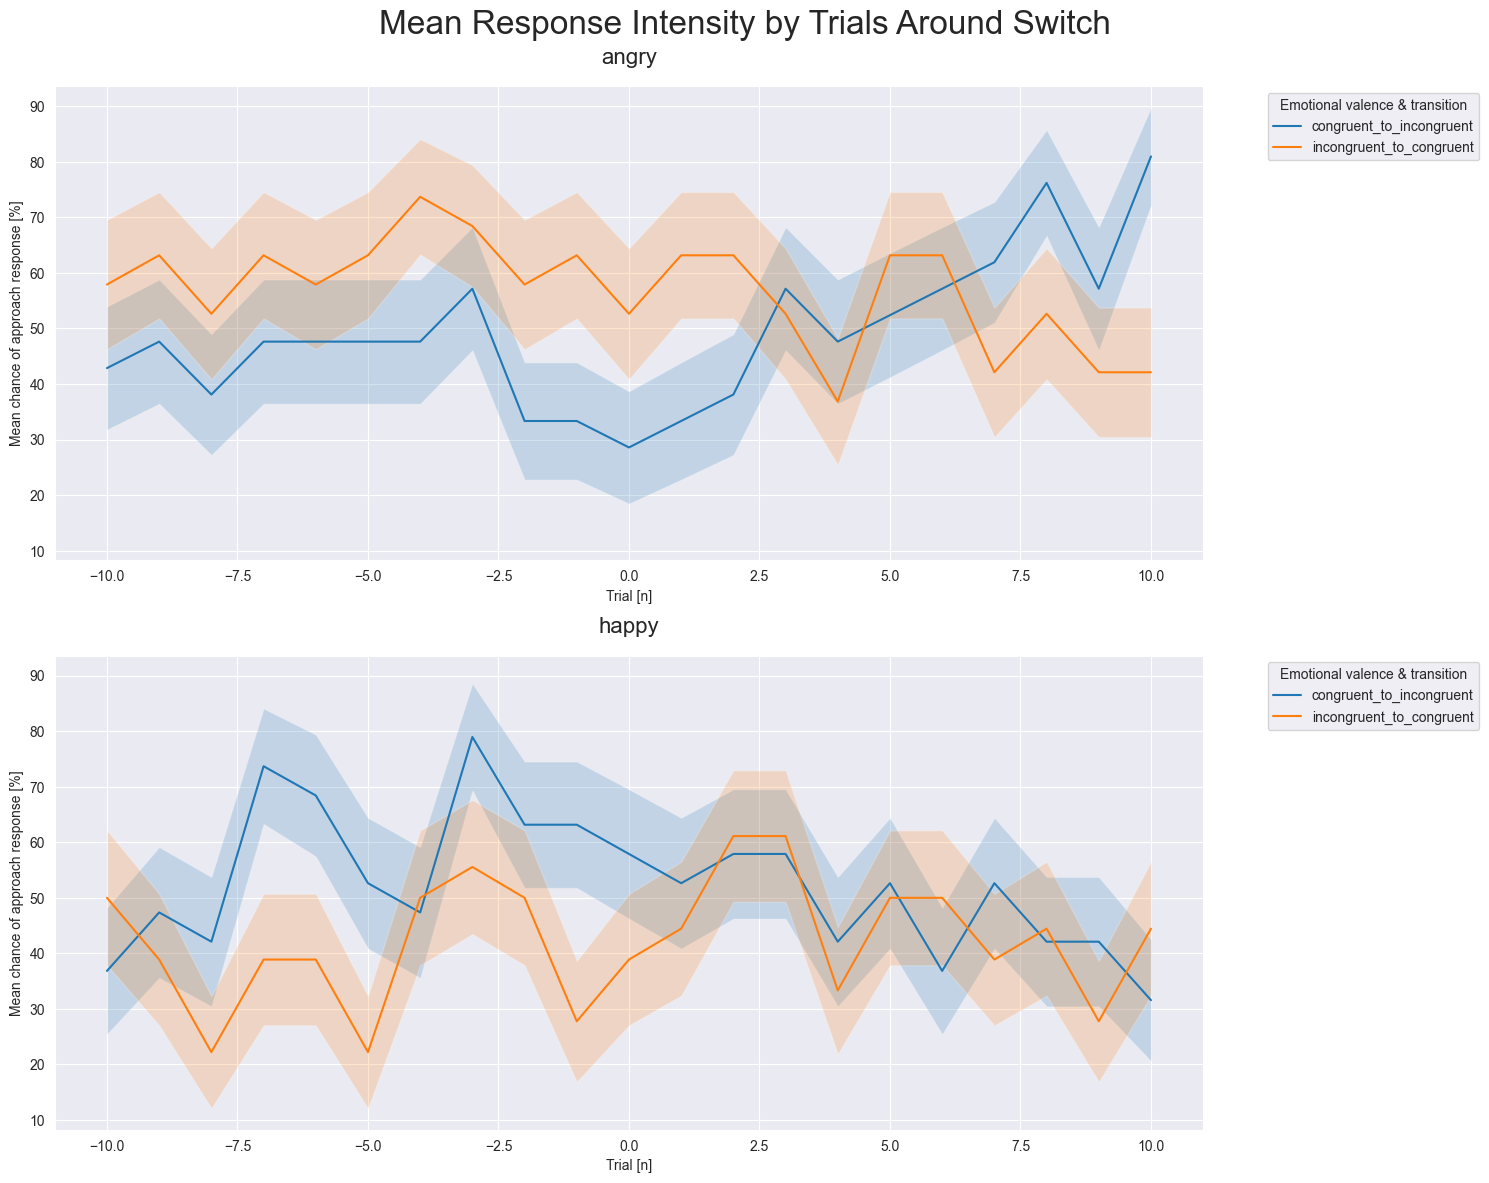

In [29]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Mean Response Intensity by Trials Around Switch', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(title='Emotional valence & transition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'Average response by emotional valence and transition grouped.pdf'))
# Show the plot
plt.show()

# Plot volatile and stable blocks separately

In [30]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
filtered_df = dataframe[dataframe['stimuli_type'] == 1]
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 11))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe,
                                                                unique_subject_ids,
                                                                unique_stimuli_types,
                                                                'volatility',
                                                                plot_range,
                                                                mapping)

print(dataframe)

    stimuli_type  subject_id volatility    0    1    2    3    4    5    6  \
0        sub-998           3   volatile    0    0  100    0    0    0    0   
1        sub-998           3   volatile  100  100  100    0  100  100    0   
2        sub-998           3   volatile    0    0    0    0    0  100    0   
3        sub-998           3   volatile    0  100    0    0  100  100  100   
4        sub-998           3   volatile    0    0    0    0    0    0  100   
..           ...         ...        ...  ...  ...  ...  ...  ...  ...  ...   
101      sub-998           1   volatile    0  100  100    0    0  100  100   
102      sub-998           1   volatile  100    0  100    0  100    0    0   
103      sub-998           1   volatile    0    0    0  100  100    0    0   
104      sub-998           1   volatile  100    0    0  100  100    0    0   
105      sub-998           1   volatile    0    0    0  100  100    0  100   

       7    8    9   10  
0      0  100  100  100  
1      0  1

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:215: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['temp_volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:216: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

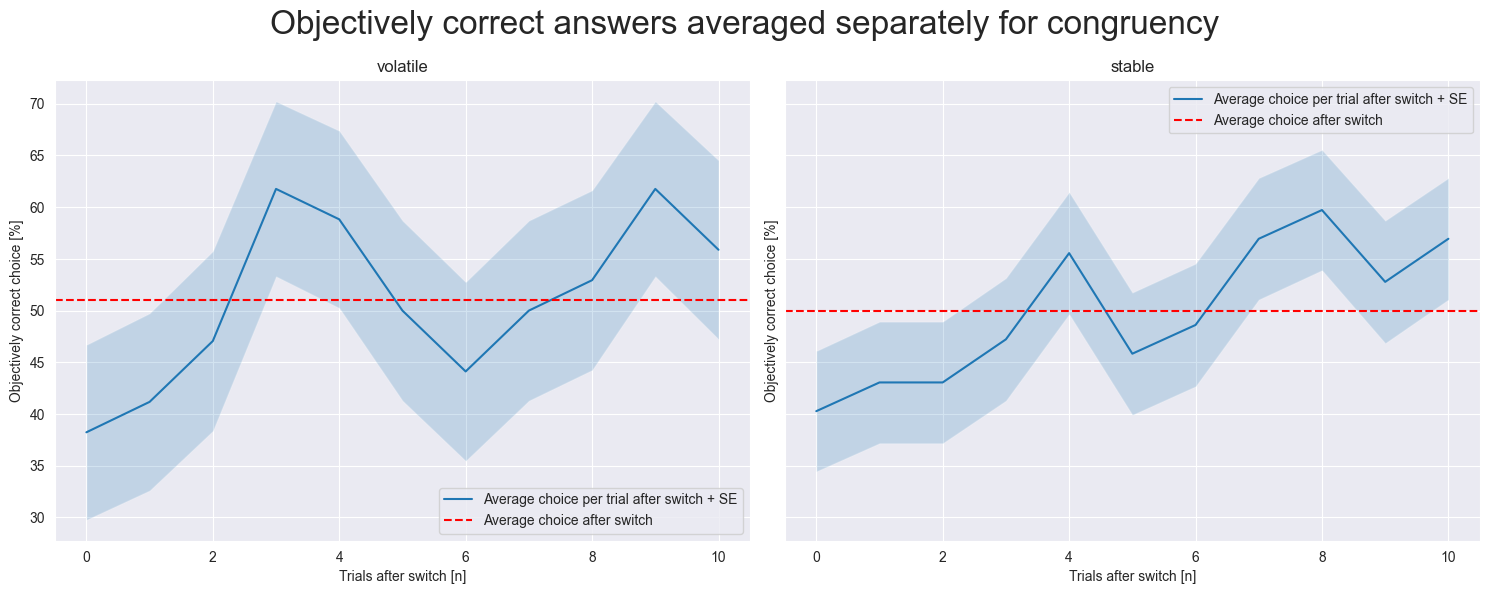

In [31]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe.set_index('volatility')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged separately for congruency', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_volatility.pdf'))
plt.show()